# Analyse statistique des données nettoyées

Ce notebook charge les fichiers CSV du sous-dossier `clean/` et affiche :
- Les analyses statistiques sur les colonnes (numériques et catégorielles)
- Les visualisations des valeurs manquantes avec **missingno**

In [21]:
# Installation des dépendances (décommenter si nécessaire)
# !pip install pandas missingno matplotlib

In [22]:
import os
import pandas as pd
import missingno as mno
import matplotlib.pyplot as plt

# Répertoire des données nettoyées (dossier clean)
for path in ["clean", os.path.join("data", "clean"), os.path.join(os.getcwd(), "clean")]:
    if os.path.exists(path):
        DATA_DIR = path
        break
else:
    raise FileNotFoundError("Dossier 'clean' introuvable. Exécutez ce notebook depuis le dossier data/.")
print(f"Chargement depuis : {os.path.abspath(DATA_DIR)}")

Chargement depuis : /home/benoit/mspr1/HEALTHAIMSRP/data/clean


In [23]:
# Chargement des fichiers CSV du dossier clean
df_food = pd.read_csv(os.path.join(DATA_DIR, "daily_food_nutrition_clean.csv"), on_bad_lines="skip")
df_diet = pd.read_csv(os.path.join(DATA_DIR, "diet_recommendations_clean.csv"), on_bad_lines="skip")
df_exercise = pd.read_csv(os.path.join(DATA_DIR, "exercise_tracker_clean.csv"), on_bad_lines="skip")

datasets = {
    "Nutrition alimentaire": df_food,
    "Recommandations diététiques": df_diet,
    "Suivi exercices (gym)": df_exercise
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} lignes × {df.shape[1]} colonnes")

Nutrition alimentaire: 645 lignes × 12 colonnes
Recommandations diététiques: 1000 lignes × 20 colonnes
Suivi exercices (gym): 1413 lignes × 15 colonnes


## 1. Statistiques descriptives (colonnes numériques)

In [24]:
def afficher_stats_numeriques(df, nom):
    """Affiche describe() pour les colonnes numériques."""
    print(f"\n{'='*60}\n{nom}\n{'='*60}")
    numeriques = df.select_dtypes(include=["number"])
    if numeriques.empty:
        print("Aucune colonne numérique.")
    else:
        display(df[numeriques.columns].describe())

for nom, df in datasets.items():
    afficher_stats_numeriques(df, nom)


Nutrition alimentaire


,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Water_Intake (ml)
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000
mean,146.294574,6.300620,15.435194,6.469612,1.702481,5.294264,246.331783,20.482171,68.700775
std,139.984360,8.782683,16.349230,8.142916,2.121275,8.537343,308.472431,43.560072,137.077115
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.500000,1.300000,0.200000,0.000000,0.400000,5.000000,0.000000,0.000000
50%,105.000000,2.700000,9.200000,3.000000,1.000000,2.000000,120.000000,0.000000,0.000000
75%,200.000000,7.000000,27.000000,10.000000,3.000000,6.000000,350.000000,25.000000,0.000000
max,680.000000,45.000000,70.000000,40.000000,14.000000,60.000000,1580.000000,450.000000,500.000000



Recommandations diététiques


,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.857000,84.602400,174.81700,28.191600,2475.064000,199.717900,144.993000,136.867600,5.166000,74.88430,2.469200
std,18.114267,20.088121,14.33377,8.040136,565.017032,29.080614,20.245712,37.934819,2.847995,14.82638,1.459631
min,18.000000,50.000000,150.00000,13.000000,1500.000000,150.400000,110.000000,70.200000,0.000000,50.00000,0.000000
25%,35.000000,66.600000,162.00000,22.075000,1984.750000,174.300000,128.000000,105.000000,2.800000,62.00000,1.200000
50%,50.000000,85.200000,175.00000,27.450000,2470.500000,199.850000,145.000000,138.000000,5.200000,74.20000,2.400000
75%,66.000000,102.000000,187.00000,33.425000,2937.250000,224.850000,163.000000,170.650000,7.600000,88.20000,3.700000
max,79.000000,119.700000,199.00000,52.400000,3498.000000,249.900000,179.000000,200.000000,10.000000,100.00000,5.000000



Suivi exercices (gym)


,Age,Weight (kg),Height (m),Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000,1413.000000
mean,34.463553,67.491578,1.739214,146.243454,63.955414,1.388669,1032.658174,23.431706,2.727035,3.346780,1.823071,20.069830
std,12.281443,19.782566,0.123758,15.334242,7.879861,0.372368,324.825181,5.911757,0.706990,0.958072,0.742177,6.633383
min,18.000000,40.000000,1.500000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,24.000000,52.300000,1.660000,133.000000,57.000000,1.130000,800.000000,20.200000,2.100000,3.000000,1.000000,14.880000
50%,33.000000,65.200000,1.730000,146.000000,65.000000,1.370000,1029.000000,24.100000,2.800000,3.000000,2.000000,18.780000
75%,45.000000,80.000000,1.820000,160.000000,72.000000,1.630000,1247.000000,27.500000,3.400000,4.000000,2.000000,23.590000
max,59.000000,129.900000,2.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


## 2. Statistiques sur les colonnes catégorielles (value_counts)

In [25]:
def afficher_stats_categorielles(df, nom):
    """Affiche value_counts pour les colonnes object/string."""
    print(f"\n{'='*60}\n{nom}\n{'='*60}")
    categorielles = df.select_dtypes(include=["object", "string"])
    for col in categorielles.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(15))

for nom, df in datasets.items():
    afficher_stats_categorielles(df, nom)


Nutrition alimentaire

--- Food_Item ---
Food_Item
Tzatziki Sauce (2 tbsp)       3
Pancakes (2 medium)           2
Maple Syrup (2 tbsp)          2
Sausage Link (1 cooked)       2
Smoothie (Fruit & Yogurt)     2
Tofu (4oz firm)               2
Brown Rice (1 cup cooked)     2
Bell Pepper (1 medium red)    2
Hummus (2 tbsp)               2
Pita Bread (1 whole wheat)    2
Pork Chop (4oz grilled)       2
Mashed Potatoes (1 cup)       2
Corn (1 cup)                  2
Soda (1 can Coke)             2
Pretzels (1 oz)               2
Name: count, dtype: int64

--- Category ---
Category
Condiment          120
Vegetable           70
Grain               59
Beverage            54
Fruit               34
Protein/Meat        31
Meal/Processed      30
Dairy               27
Dessert             27
Meal/Meat           20
Meal/Pasta          16
Snack/Processed     16
Nut                 14
Legume              11
Meal/Vegetarian     10
Name: count, dtype: int64

--- Meal_Type ---
Meal_Type
Dinner       22

## 3. Valeurs manquantes par colonne

In [26]:
for nom, df in datasets.items():
    print(f"\n{nom}")
    print("-" * 40)
    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    result = pd.DataFrame({"Manquants": missing, "%": missing_pct})
    result = result[result["Manquants"] > 0].sort_values("Manquants", ascending=False)
    if result.empty:
        print("Aucune valeur manquante.")
    else:
        display(result)


Nutrition alimentaire
----------------------------------------
Aucune valeur manquante.

Recommandations diététiques
----------------------------------------
Aucune valeur manquante.

Suivi exercices (gym)
----------------------------------------
Aucune valeur manquante.


## 4. Visualisations missingno

### 4.1 Matrice des valeurs manquantes

<Figure size 1200x600 with 0 Axes>

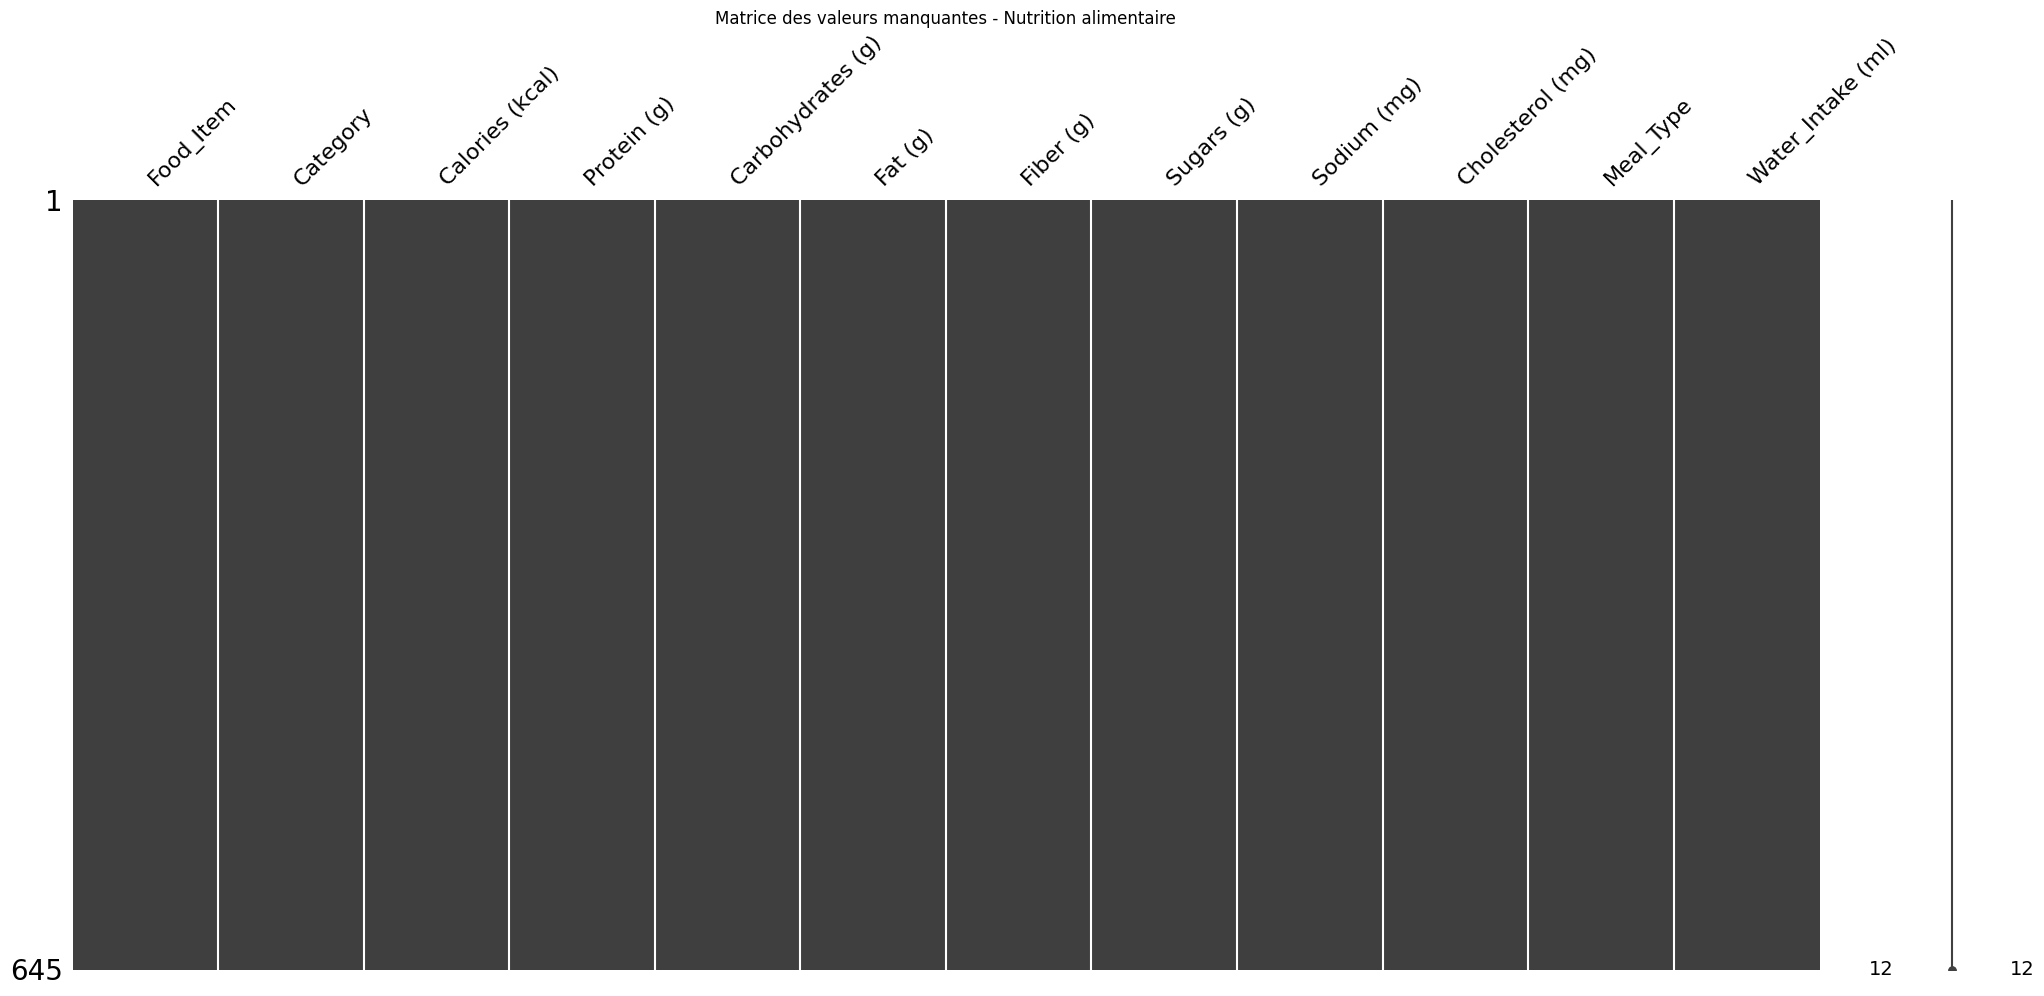

<Figure size 1200x600 with 0 Axes>

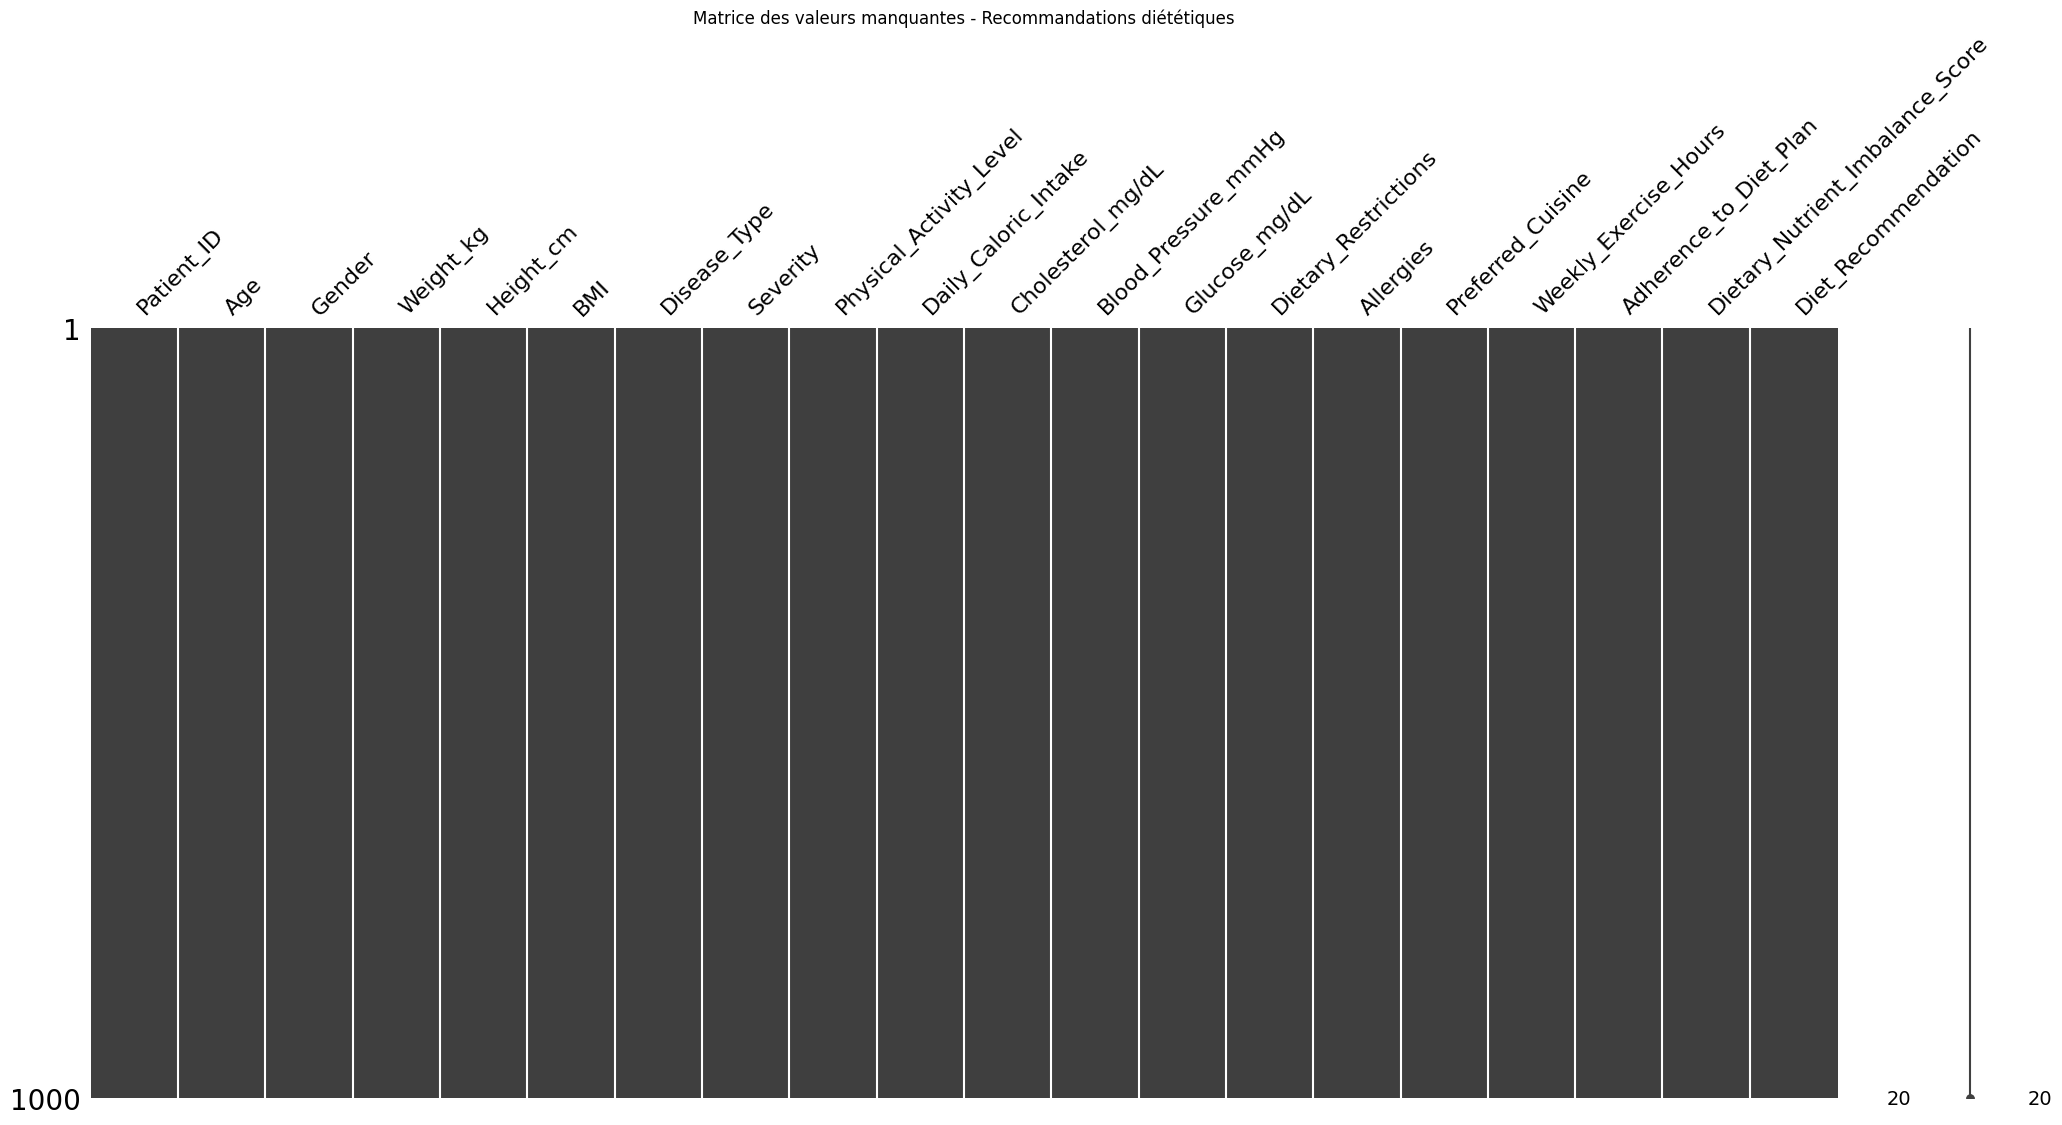

<Figure size 1200x600 with 0 Axes>

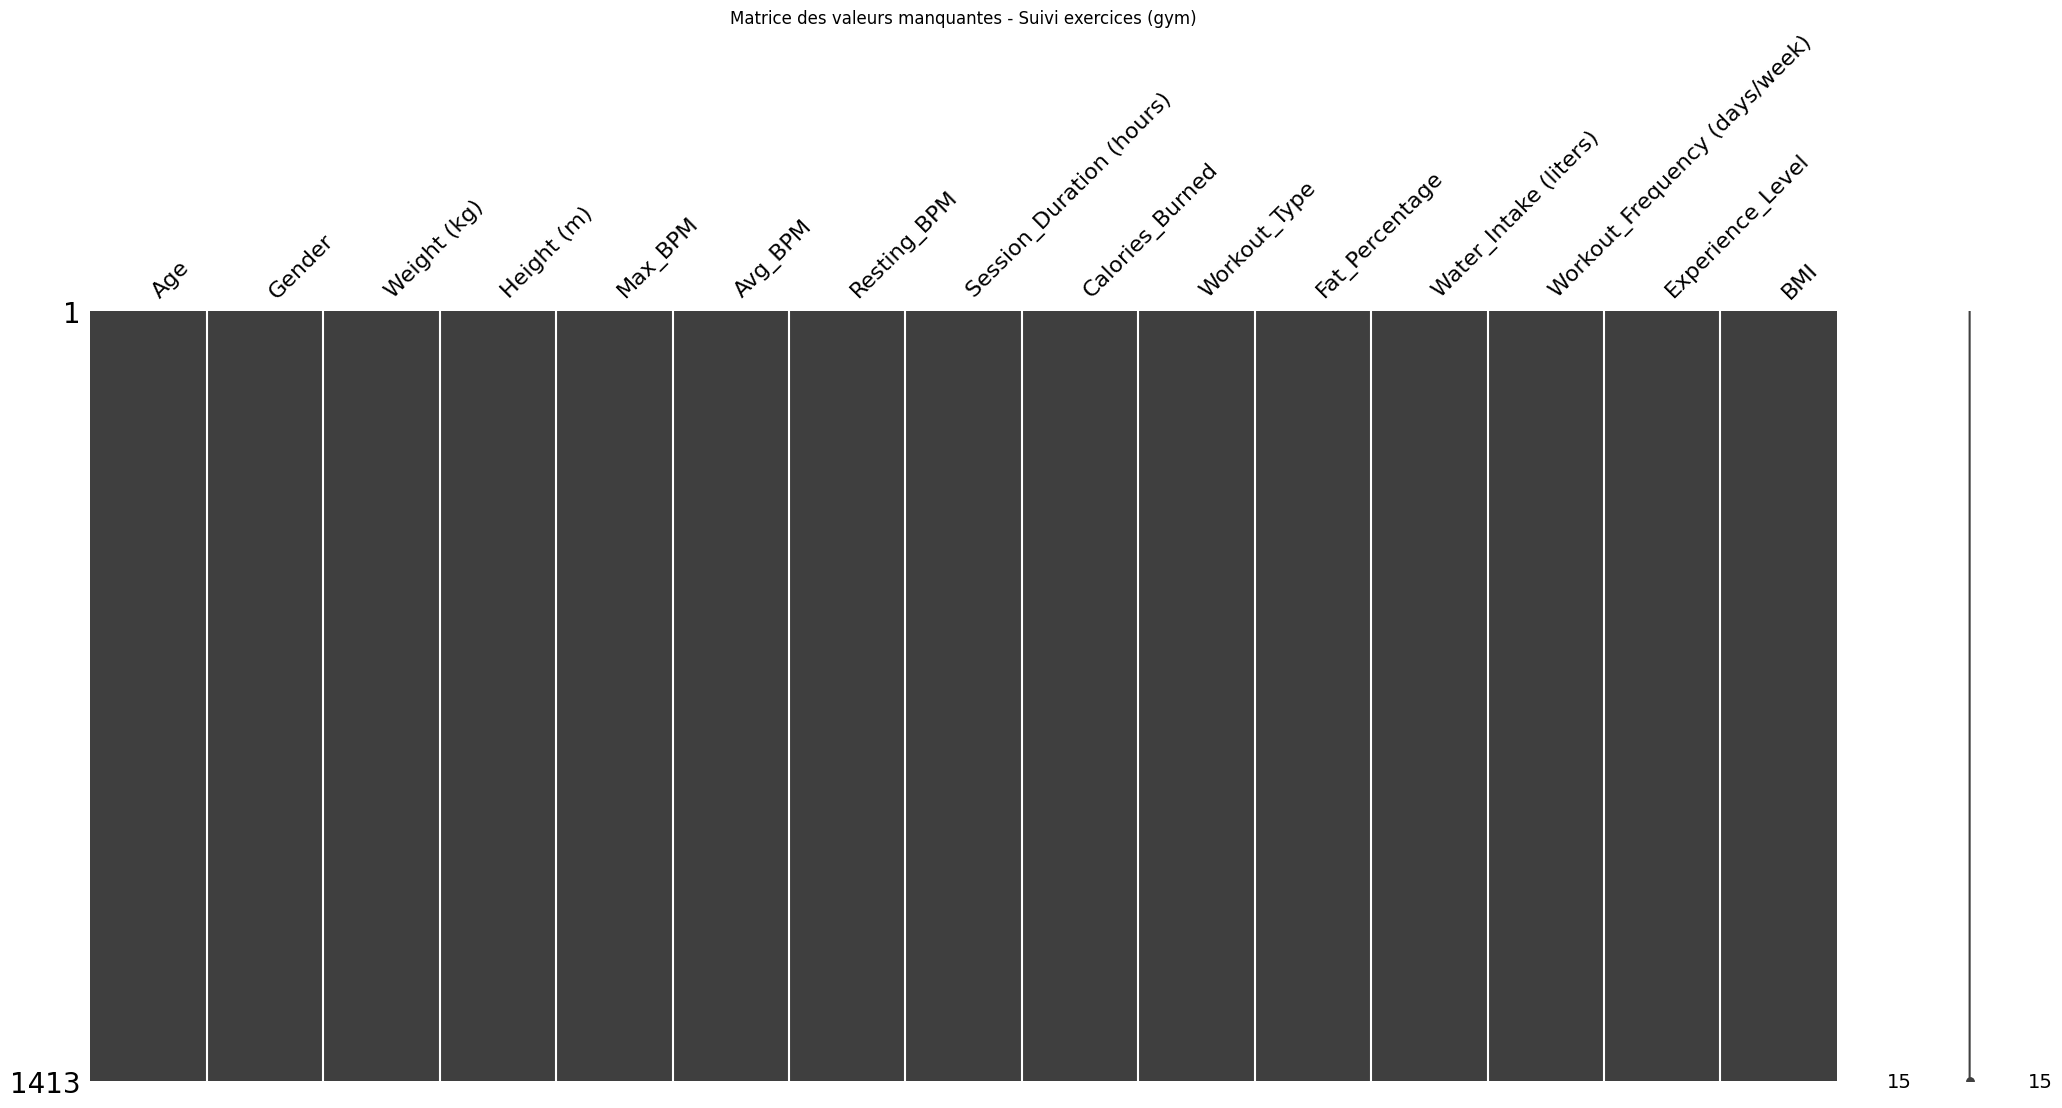

In [27]:
for nom, df in datasets.items():
    plt.figure(figsize=(12, 6))
    mno.matrix(df)
    plt.title(f"Matrice des valeurs manquantes - {nom}")
    plt.show()

### 4.2 Barres des valeurs manquantes par colonne

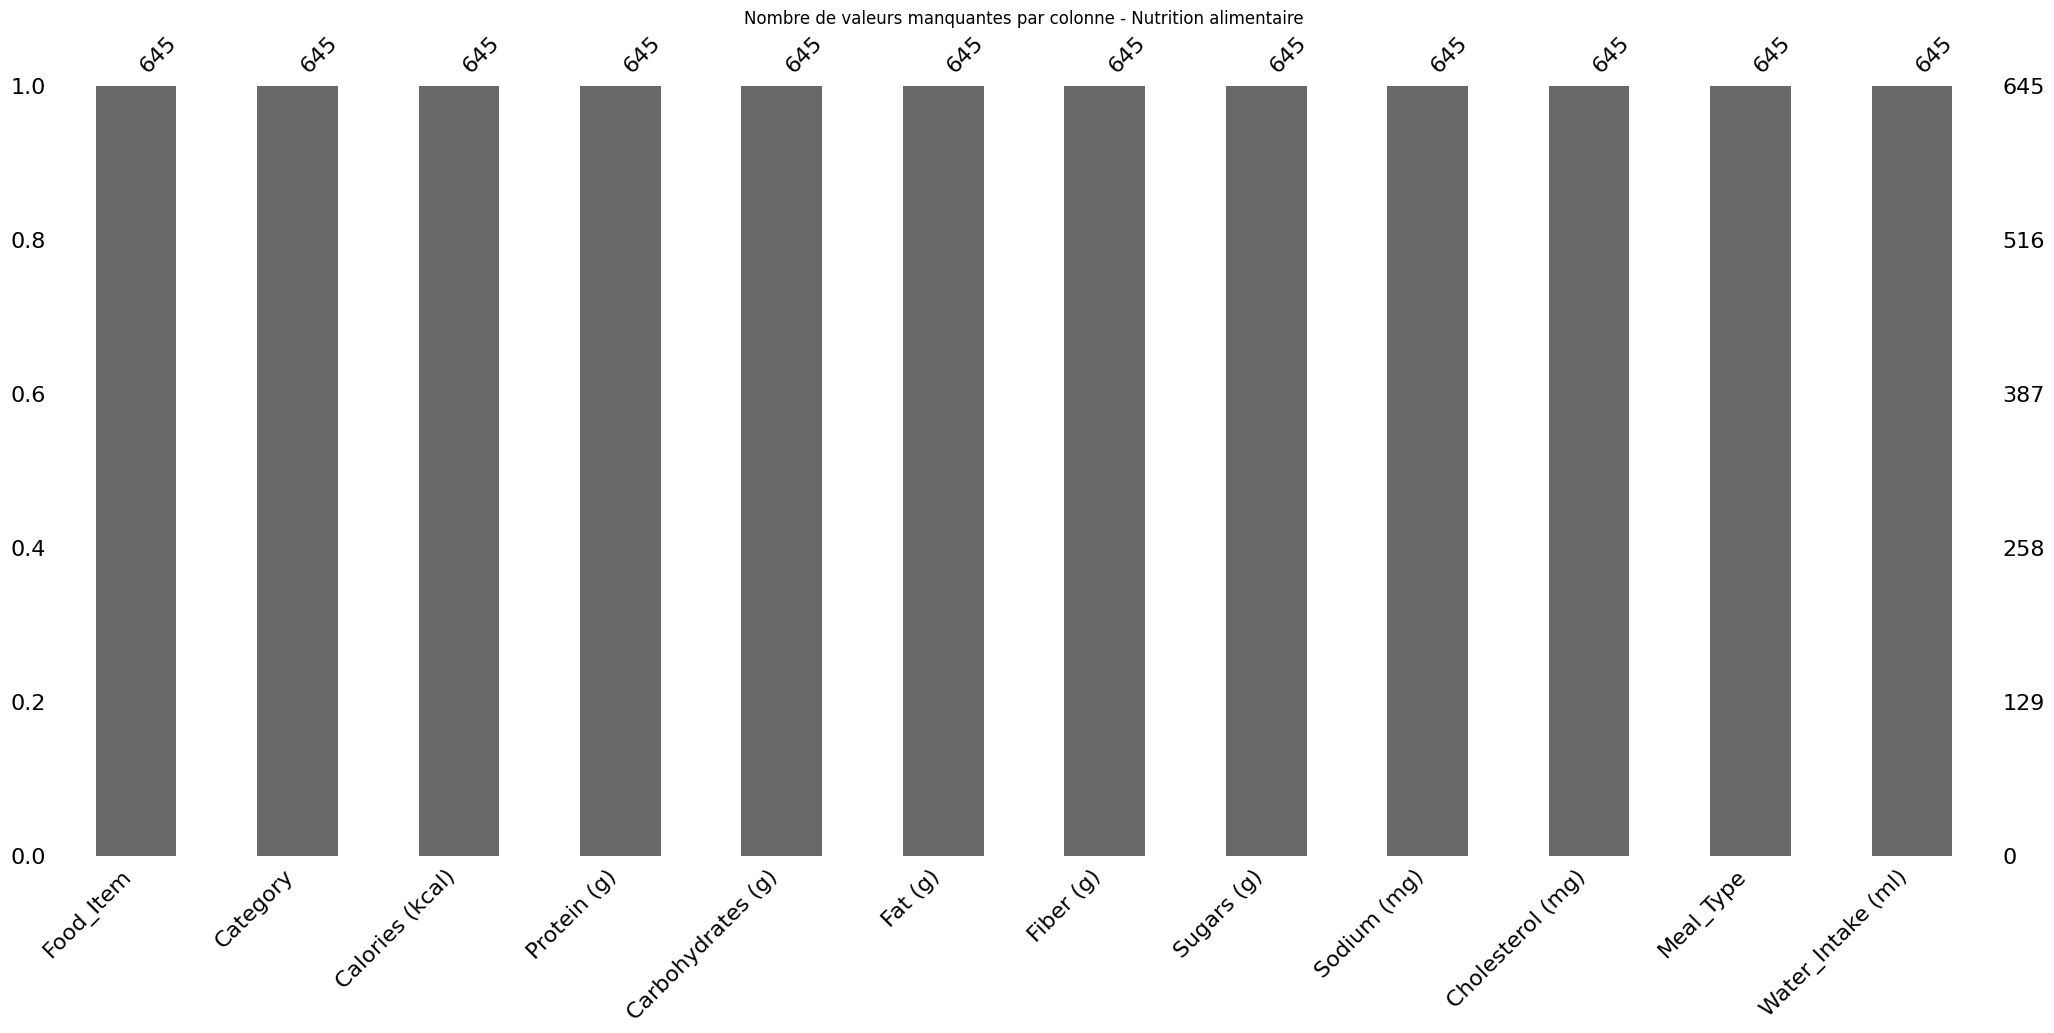

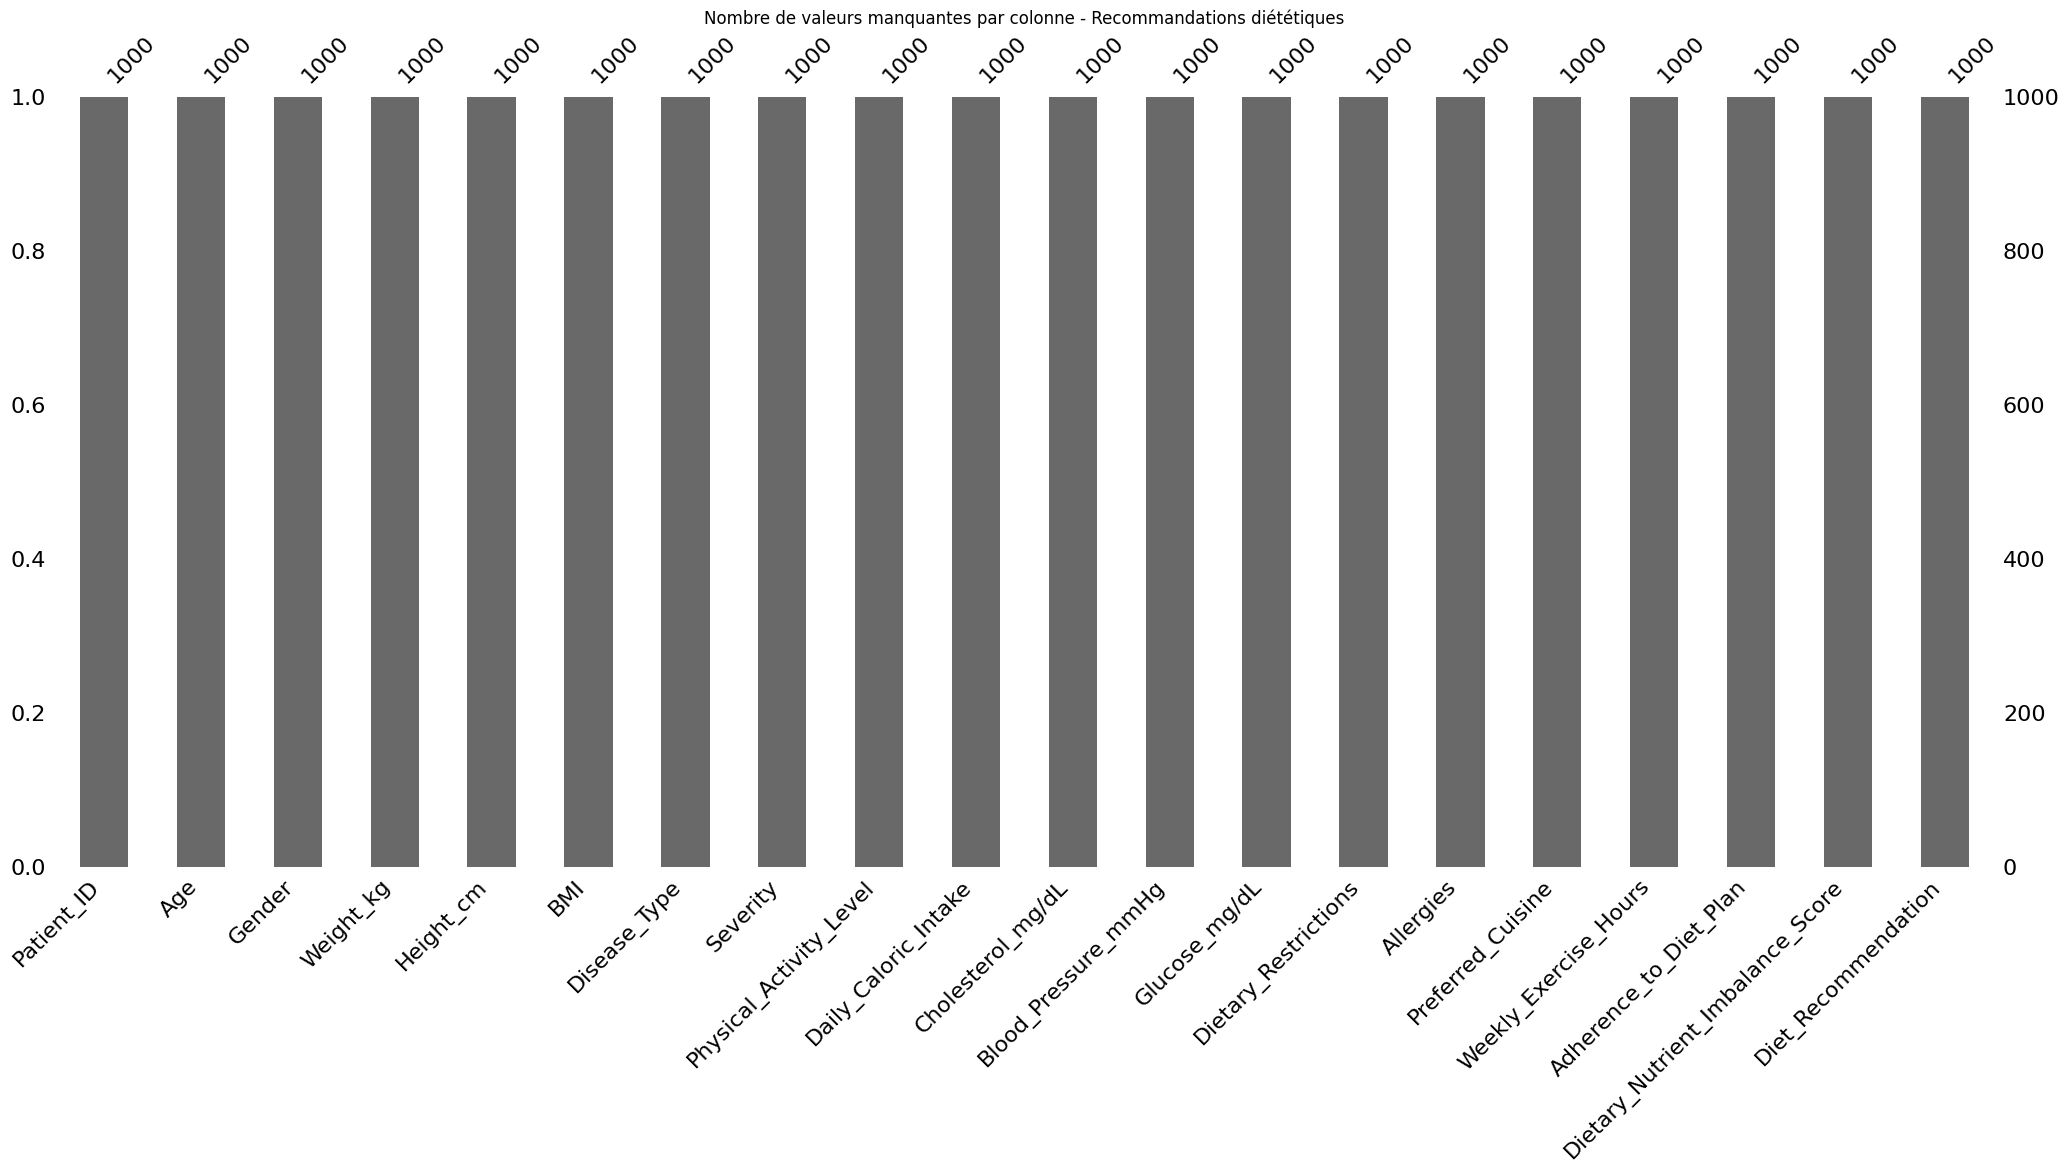

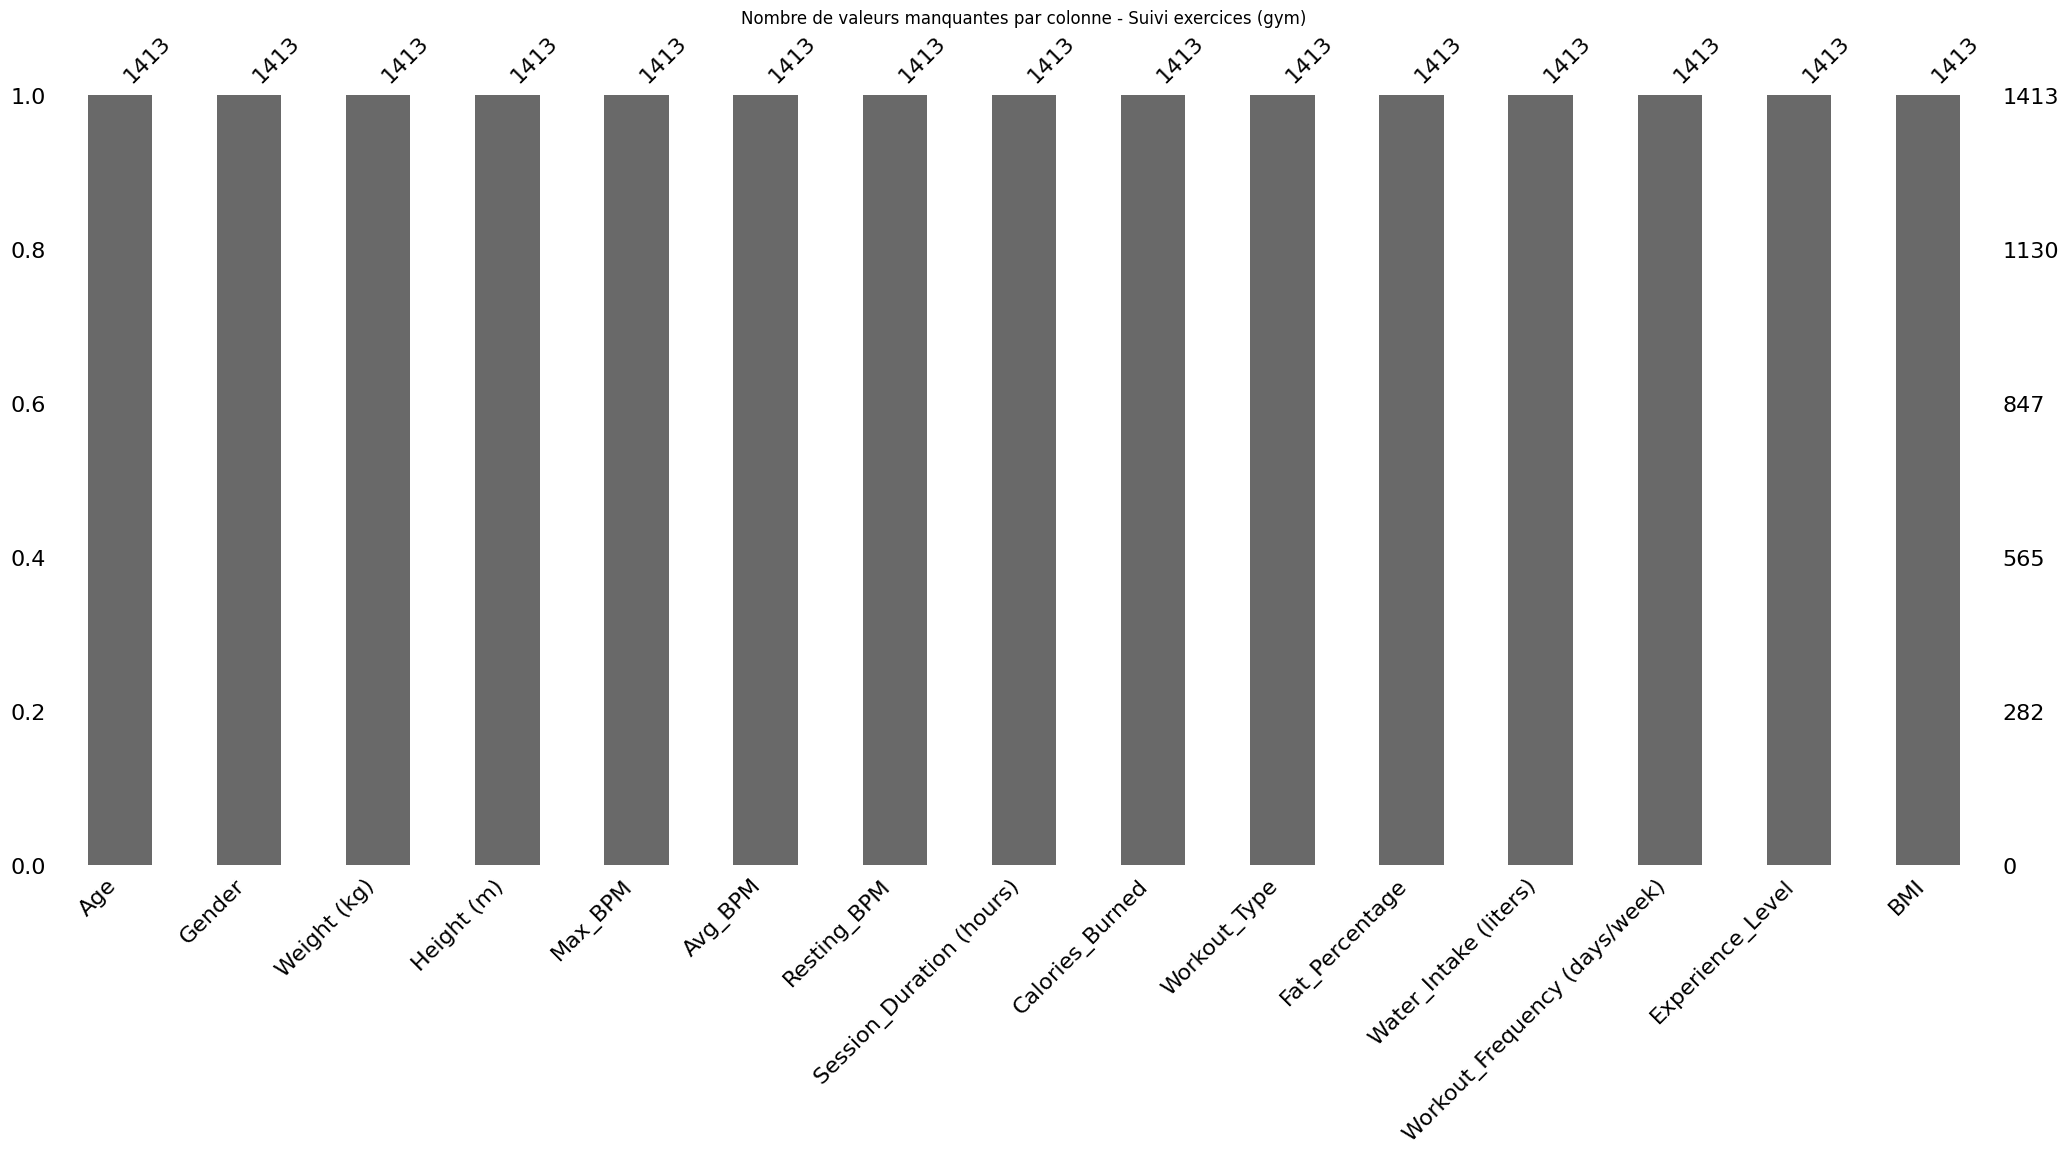

In [28]:
for nom, df in datasets.items():
    plt.figure(figsize=(10, 5))
    mno.bar(df)
    plt.title(f"Nombre de valeurs manquantes par colonne - {nom}")
    plt.show()